# MindRL + HSSM: `4AB_RW_InvTempSoftmax`

This notebook develops a four-arm Rescorla–Wagner model from its
cognitive mechanism through Bayesian fitting and posterior predictive
checks. It is written for readers who know Python and basic Bayesian
modeling but are new to HSSM's reinforcement-learning interface.

By the end, you will be able to:

1. identify which APIs belong to ssms and which belong to HSSM;
2. define an episode-reset Rescorla–Wagner learner and softmax policy;
3. bridge that model into `hssm.RLSSM` with formulas and priors;
4. fit participants with NumPyro and inspect sampler diagnostics; and
5. run causal train/held-out posterior predictive checks.

The supplied trial and reward-schedule files are the only external
inputs used by this tutorial.

## 1. Orientation and API ownership

The workflow crosses two libraries, but each has a distinct role:

| Layer | Responsibility in this notebook |
| --- | --- |
| **ssms** | Task Environment, Learning Process, Decision Process, `ModelConfig`, and sequential simulation |
| **HSSM** | `RLSSMConfig` bridge, parameter formulas and priors, `RLSSM`, Bayesian inference, and posterior samples |
| **Notebook helpers** | Data loading, repeated participant fits, diagnostics, PPC assembly, and plotting |

The visible cells teach the ssms and HSSM APIs. Incidental notebook
mechanics are collected in one expandable support cell below.

### Setup

This notebook uses the four data files listed in the Data contract
section and fixed settings so that the displayed results are
reproducible.

In [1]:
import arviz as az
import hssm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ssms.rl as rl

hssm.set_floatX("float32", update_jax=True)

SEED = 20260707
INITIAL_Q = 0.5
N_ACTIONS = 4
DRAWS = 300
TUNE = 700
CHAINS = 2
CORES = 1
TARGET_ACCEPT = 0.9
SAMPLER = "numpyro"
INIT_ALPHA = 0.6
INIT_BETA = 8.0
N_PPC_SIMULATIONS = 5
SHOW_REWARD_CEILING = True

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### Implementation support — collapsed by default

This cell contains data loading, posterior extraction, repeated-fit
bookkeeping, diagnostics, PPC assembly, and plotting orchestration.
Expand it when you want implementation details; none of its functions
define the cognitive model or the HSSM interface.

In [2]:
import json
import math
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path

from IPython.utils.capture import capture_output

from collections.abc import Sequence

SPLIT_ORDER = ("train", "heldout")
CHOICE_COLUMNS = {
    "split",
    "participant_id",
    "trajectory_id",
    "trial_id",
    "response",
}
SCHEDULE_COLUMNS = {"trajectory_id", "trial_id", "action", "latent_reward"}


def _require_columns(frame: pd.DataFrame, required: set[str], name: str) -> None:
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"{name} is missing columns: {missing}")


def _normalized_schedules(reward_schedules: pd.DataFrame) -> pd.DataFrame:
    _require_columns(reward_schedules, SCHEDULE_COLUMNS, "reward_schedules")
    schedules = reward_schedules.loc[:, sorted(SCHEDULE_COLUMNS)].copy()
    schedules["trajectory_id"] = schedules["trajectory_id"].astype(str)
    schedules["trial_id"] = schedules["trial_id"].astype(int)
    schedules["action"] = schedules["action"].astype(int)
    schedules["latent_reward"] = pd.to_numeric(
        schedules["latent_reward"], errors="coerce"
    )
    key = ["trajectory_id", "trial_id", "action"]
    if schedules.duplicated(key).any():
        raise ValueError("reward_schedules contains duplicate action rows")
    if not np.isfinite(schedules["latent_reward"]).all():
        raise ValueError("reward_schedules contains non-finite latent rewards")
    schedules["best_latent_reward"] = schedules.groupby(
        ["trajectory_id", "trial_id"], sort=False
    )["latent_reward"].transform("max")
    return schedules


def _attach_chosen_reward(
    choices: pd.DataFrame,
    reward_schedules: pd.DataFrame,
    *,
    name: str,
) -> pd.DataFrame:
    _require_columns(choices, CHOICE_COLUMNS, name)
    frame = choices.copy()
    frame["participant_id"] = frame["participant_id"].astype(str)
    frame["trajectory_id"] = frame["trajectory_id"].astype(str)
    frame["trial_id"] = frame["trial_id"].astype(int)
    frame["response"] = frame["response"].astype(int)
    schedules = _normalized_schedules(reward_schedules).rename(
        columns={"action": "response", "latent_reward": "chosen_latent_reward"}
    )
    merged = frame.merge(
        schedules,
        on=["trajectory_id", "trial_id", "response"],
        how="left",
        validate="many_to_one",
    )
    if merged[["chosen_latent_reward", "best_latent_reward"]].isna().any().any():
        raise ValueError(f"{name} has choices with missing latent rewards")
    return merged


def _participant_trial_means(
    frame: pd.DataFrame,
    *,
    extra_group_cols: Sequence[str] = (),
) -> pd.DataFrame:
    group_cols = ["split", *extra_group_cols, "participant_id", "trial_id"]
    return (
        frame.groupby(group_cols, sort=True, as_index=False)
        .agg(
            chosen_latent_reward=("chosen_latent_reward", "mean"),
            best_latent_reward=("best_latent_reward", "mean"),
        )
        .reset_index(drop=True)
    )


def build_latent_reward_summary(
    observed_choices: pd.DataFrame,
    simulated_choices: pd.DataFrame,
    reward_schedules: pd.DataFrame,
    *,
    hdi_prob: float = 0.94,
) -> pd.DataFrame:
    """Summarize empirical and replicated chosen rewards by split and trial."""
    if not 0.0 < hdi_prob <= 1.0:
        raise ValueError("hdi_prob must be in (0, 1]")
    _require_columns(simulated_choices, {"simulation"}, "simulated_choices")

    observed_reward = _attach_chosen_reward(
        observed_choices, reward_schedules, name="observed_choices"
    )
    simulated_reward = _attach_chosen_reward(
        simulated_choices, reward_schedules, name="simulated_choices"
    )
    observed_participant = _participant_trial_means(observed_reward)
    simulated_participant = _participant_trial_means(
        simulated_reward, extra_group_cols=("simulation",)
    )

    observed_summary = observed_participant.groupby(
        ["split", "trial_id"], sort=True
    ).agg(
        empirical_mean=("chosen_latent_reward", "mean"),
        ceiling_mean=("best_latent_reward", "mean"),
        n_participants=("participant_id", "nunique"),
    )
    replicate_summary = (
        simulated_participant.groupby(
            ["split", "trial_id", "simulation"], sort=True, as_index=False
        )["chosen_latent_reward"]
        .mean()
        .rename(columns={"chosen_latent_reward": "replicate_mean"})
    )

    rows: list[dict[str, float | int | str]] = []
    for (split, trial_id), observed_row in observed_summary.iterrows():
        replicate_values = replicate_summary.loc[
            (replicate_summary["split"] == split)
            & (replicate_summary["trial_id"] == trial_id),
            "replicate_mean",
        ].to_numpy(dtype=float)
        if not len(replicate_values):
            raise ValueError(f"No simulations for split={split!r}, trial_id={trial_id}")
        hdi = np.asarray(az.hdi(replicate_values, prob=hdi_prob), dtype=float)
        rows.append(
            {
                "split": str(split),
                "trial_id": int(trial_id),
                "empirical_mean": float(observed_row["empirical_mean"]),
                "simulated_mean": float(replicate_values.mean()),
                "simulated_hdi_low": float(hdi[0]),
                "simulated_hdi_high": float(hdi[1]),
                "ceiling_mean": float(observed_row["ceiling_mean"]),
                "n_participants": int(observed_row["n_participants"]),
                "n_simulations": int(len(replicate_values)),
            }
        )
    return pd.DataFrame.from_records(rows)


def plot_latent_reward_ppc(
    summary: pd.DataFrame,
    *,
    show_ceiling: bool = True,
):
    """Plot participant-balanced latent-reward PPC trends by data split."""
    import matplotlib.pyplot as plt

    required = {
        "split",
        "trial_id",
        "empirical_mean",
        "simulated_mean",
        "simulated_hdi_low",
        "simulated_hdi_high",
        "ceiling_mean",
    }
    _require_columns(summary, required, "summary")
    fig, raw_axes = plt.subplots(1, 2, figsize=(11.0, 4.0), sharey=True)
    axes = dict(zip(SPLIT_ORDER, raw_axes, strict=True))
    titles = {"train": "Train", "heldout": "Held-out"}
    for split, ax in axes.items():
        data = summary.loc[summary["split"] == split].sort_values("trial_id")
        if data.empty:
            ax.set_axis_off()
            continue
        x = data["trial_id"].to_numpy(dtype=float)
        ax.plot(
            x,
            data["empirical_mean"].to_numpy(dtype=float),
            color="#5f5f5f",
            linewidth=1.8,
            label="Empirical mean",
        )
        ax.fill_between(
            x,
            data["simulated_hdi_low"].to_numpy(dtype=float),
            data["simulated_hdi_high"].to_numpy(dtype=float),
            color="#386cb0",
            alpha=0.2,
            linewidth=0,
        )
        ax.plot(
            x,
            data["simulated_mean"].to_numpy(dtype=float),
            color="#386cb0",
            linewidth=1.8,
            label="Simulated mean",
        )
        if show_ceiling:
            ax.plot(
                x,
                data["ceiling_mean"].to_numpy(dtype=float),
                color="#1b1b1b",
                linestyle=":",
                linewidth=1.3,
                label="Best available reward",
            )
        ax.set_title(titles[split])
        ax.set_xlabel("Trial index")
        ax.set_ylim(0.0, 1.0)
    axes["train"].set_ylabel("Mean latent reward")
    handles, labels = axes["train"].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="lower center", ncol=len(handles))
    fig.tight_layout(rect=(0, 0.12, 1, 1))
    return fig, axes


FIT_COLS = ["participant_id", "response", "feedback", "episode_start"]
PPC_OBSERVED_COLS = [
    "participant_id",
    "trial_id",
    "response",
    "feedback",
    "episode_start",
]
CHOICE_ID_COLS = ["participant_id", "trajectory_id", "trial_id"]


def make_hssm_model(data):
    return hssm.RLSSM(
        data=data,
        model_config=hssm_model_config,
        include=model_parameters,
        p_outlier=0,
        lapse=None,
        process_initvals=False,
    )


def fit_subject(subject_id, train_df):
    fit_data = train_df.loc[
        train_df["participant_id"] == subject_id,
        FIT_COLS,
    ].reset_index(drop=True)
    rl_model_config.validate_data(fit_data).raise_for_errors()
    model = make_hssm_model(fit_data)
    return model.sample(
        sampler=SAMPLER,
        draws=DRAWS,
        tune=TUNE,
        chains=CHAINS,
        cores=CORES,
        target_accept=TARGET_ACCEPT,
        initvals={
            "rl_alpha_Intercept": INIT_ALPHA,
            "beta_Intercept": INIT_BETA,
        },
        idata_kwargs={"log_likelihood": False},
        random_seed=SEED,
        progressbar=False,
    )


def load_tutorial_data():
    DATA_DIR = Path("data")
    train = pd.read_csv(DATA_DIR / "train_trials.csv")
    heldout = pd.read_csv(DATA_DIR / "heldout_trials.csv")
    schedules = pd.read_csv(DATA_DIR / "reward_schedules.csv")
    splits = json.loads((DATA_DIR / "splits.json").read_text())

    all_subjects = sorted(splits)
    subjects = all_subjects
    train = train[train["participant_id"].isin(subjects)].reset_index(drop=True)
    heldout = heldout[
        heldout["participant_id"].isin(subjects)
    ].reset_index(drop=True)
    trajectories = set(train["trajectory_id"]) | set(heldout["trajectory_id"])
    schedules = schedules[
        schedules["trajectory_id"].isin(trajectories)
    ].reset_index(drop=True)

    for subject_id in subjects:
        subject_train = train[train["participant_id"] == subject_id]
        subject_heldout = heldout[heldout["participant_id"] == subject_id]
        assert subject_train["trajectory_id"].nunique() == 3
        assert subject_heldout["trajectory_id"].nunique() == 1
        assert set(splits[subject_id]["train"]) == set(
            subject_train["trajectory_id"].unique()
        )
        assert set(splits[subject_id]["heldout"]) == set(
            subject_heldout["trajectory_id"].unique()
        )

    coverage = schedules.groupby(["trajectory_id", "trial_id"])[
        "action"
    ].nunique()
    assert schedules["trajectory_id"].nunique() == 4 * len(subjects)
    assert coverage.eq(N_ACTIONS).all()
    return (
        train,
        heldout,
        schedules,
        subjects,
    )


def _posterior_dataset(idata):
    posterior = idata.posterior
    return posterior.to_dataset() if hasattr(posterior, "to_dataset") else posterior


def extract_posterior_means(idata) -> dict[str, float]:
    posterior = _posterior_dataset(idata)

    def mean_of(*names):
        for name in names:
            if name in posterior:
                return float(posterior[name].mean())
        raise KeyError(names)

    return {
        "rl_alpha": mean_of("rl_alpha", "rl_alpha_Intercept", "Intercept"),
        "beta": mean_of("beta", "beta_Intercept"),
    }


def extract_posterior_draws(idata, n_draws: int, seed: int) -> list[dict]:
    posterior = _posterior_dataset(idata)

    def values(*names):
        for name in names:
            if name in posterior:
                return np.asarray(posterior[name], dtype=np.float64).reshape(-1)
        raise KeyError(names)

    alpha = values("rl_alpha", "rl_alpha_Intercept", "Intercept")
    beta = values("beta", "beta_Intercept")
    n = min(int(n_draws), len(alpha))
    indices = np.sort(
        np.random.default_rng(seed).choice(len(alpha), size=n, replace=False)
    )
    return [
        {
            "posterior_draw": int(index),
            "rl_alpha": float(alpha[index]),
            "beta": float(beta[index]),
        }
        for index in indices
    ]


def diagnostic_flags(idata) -> dict:
    summary = az.summary(
        idata,
        var_names=["rl_alpha", "beta"],
        filter_vars="like",
    )
    max_rhat = (
        float(summary["r_hat"].max())
        if "r_hat" in summary
        else float("nan")
    )
    min_ess = (
        float(summary["ess_bulk"].min())
        if "ess_bulk" in summary
        else float("nan")
    )
    divergences = 0
    if hasattr(idata, "sample_stats") and idata.sample_stats is not None:
        if "diverging" in idata.sample_stats:
            divergences = int(idata.sample_stats["diverging"].sum())
    return {
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess,
        "divergences": divergences,
        "passed": bool(
            math.isfinite(max_rhat)
            and max_rhat < 1.05
            and divergences == 0
        ),
    }


def fit_all_subjects(subjects, train_df):
    fit_results = {}
    rows = []
    print(f"Fitting {len(subjects)} participants (sampler chatter suppressed) ...")
    for subject_id in subjects:
        with capture_output():
            idata = fit_subject(subject_id, train_df)
        means = extract_posterior_means(idata)
        diagnostics = diagnostic_flags(idata)
        fit_results[subject_id] = {
            "idata": idata,
            "means": means,
            "diagnostics": diagnostics,
        }
        rows.append(
            {
                "subject_id": subject_id,
                "rl_alpha_mean": means["rl_alpha"],
                "beta_mean": means["beta"],
                **diagnostics,
            }
        )
    print("Finished participant fits; inspect the table below for diagnostics.")
    return fit_results, pd.DataFrame(rows).set_index("subject_id")


def plot_parameter_summary(fit_summary):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    x = np.arange(len(fit_summary))
    axes[0].bar(x, fit_summary["rl_alpha_mean"], color="#4c72b0")
    axes[0].set_ylabel(r"posterior mean $\alpha$")
    axes[0].set_title("Learning rate (train fits)")
    axes[1].bar(x, fit_summary["beta_mean"], color="#dd8452")
    axes[1].set_ylabel(r"posterior mean $\beta$")
    axes[1].set_title("Inverse temperature (train fits)")
    for axis in axes:
        axis.set_xticks(x)
        axis.set_xticklabels(
            fit_summary.index,
            rotation=60,
            ha="right",
            fontsize=7,
        )
    fig.tight_layout()
    return fig, axes


def _simulate_subject_split(observed, *, split, posterior_draws, seed):
    simulator = rl.Simulator(rl_model_config)
    simulator_observed = observed.loc[:, PPC_OBSERVED_COLS].reset_index(drop=True)
    identifiers = observed.loc[:, CHOICE_ID_COLS].reset_index(drop=True)
    frames = []
    for simulation, draw in enumerate(posterior_draws):
        simulated = simulator.simulate(
            theta={
                "rl_alpha": draw["rl_alpha"],
                "beta": draw["beta"],
            },
            mode="ppc",
            observed_data=simulator_observed,
            random_state=seed + simulation,
        ).reset_index(drop=True)
        frame = identifiers.copy()
        frame["split"] = split
        frame["simulation"] = simulation
        frame["response"] = simulated["response"].astype(int).to_numpy()
        frames.append(frame)
    return frames


def run_latent_reward_ppc(
    fit_results,
    subjects,
    train,
    heldout,
    reward_schedules,
    *,
    n_simulations,
    seed,
):
    draws_by_subject = {
        subject_id: extract_posterior_draws(
            fit_results[subject_id]["idata"],
            n_draws=n_simulations,
            seed=seed + index,
        )
        for index, subject_id in enumerate(subjects)
    }
    actual_k = min(len(draws) for draws in draws_by_subject.values())
    if actual_k < 1:
        raise ValueError("At least one posterior draw is required for PPC.")

    simulated_frames = []
    print(
        f"Simulating {actual_k} train/held-out PPC datasets for "
        f"{len(subjects)} participants ..."
    )
    with redirect_stdout(StringIO()), redirect_stderr(StringIO()):
        for index, subject_id in enumerate(subjects):
            subject_frames = (
                (
                    "train",
                    train[
                        train["participant_id"] == subject_id
                    ].reset_index(drop=True),
                ),
                (
                    "heldout",
                    heldout[
                        heldout["participant_id"] == subject_id
                    ].reset_index(drop=True),
                ),
            )
            for split_name, frame in subject_frames:
                simulated_frames.extend(
                    _simulate_subject_split(
                        frame,
                        split=split_name,
                        posterior_draws=draws_by_subject[subject_id][
                            :actual_k
                        ],
                        seed=seed
                        + 1000 * index
                        + (0 if split_name == "train" else 500),
                    )
                )

    observed_choices = pd.concat([train, heldout], ignore_index=True)[
        ["split", *CHOICE_ID_COLS, "response"]
    ]
    simulated_choices = pd.concat(simulated_frames, ignore_index=True)
    summary = build_latent_reward_summary(
        observed_choices,
        simulated_choices,
        reward_schedules,
        hdi_prob=0.94,
    )
    return summary, actual_k

## 2. Data contract

HSSM receives one chronological long-format panel per participant. The
fitted RLSSM uses only four columns:

| Column | Meaning |
| --- | --- |
| `participant_id` | panel identifier |
| `response` | observed action, encoded 0–3 |
| `feedback` | received reward divided by 100 |
| `episode_start` | reset Q-values before this trial when equal to 1 |

The supplied files contain three 120-trial training episodes and one
held-out episode per participant. The full reward schedule is loaded
only for the final diagnostic; it never enters fitting or prediction.

In [3]:
(
    train,
    heldout,
    reward_schedules,
    subjects,
) = load_tutorial_data()

print("Participants:", len(subjects))
print("Train:", train.shape, "| Held-out:", heldout.shape)
demo_subject = subjects[0]
demo_train = train.loc[
    train["participant_id"] == demo_subject,
    FIT_COLS,
].reset_index(drop=True)
train.loc[:, FIT_COLS].head()

Participants: 25
Train: (9000, 8) | Held-out: (3000, 8)


,participant_id,response,feedback,episode_start
0,sub_000010,0,0.80,1
1,sub_000010,0,0.72,0
2,sub_000010,0,0.70,0
3,sub_000010,0,0.78,0
4,sub_000010,0,0.67,0


## 3. Define the cognitive RL model

The model combines a task environment, a learning process, and a
decision process. `rl.ModelConfig` is the ssms-side contract that binds
those pieces and declares the response/context fields and bounds.

### Task Environment

The task environment declares the four choices and the feedback field
used by ssms. A proper trial-by-action reward schedule is needed for
free generative simulation. This tutorial instead uses the supplied
feedback column and the custom observed-history PPC script, so the
schedule is never passed to the likelihood.

In [4]:
class NonStationaryGaussianBandit:
    # Four-choice environment with an optional changing reward schedule.

    def __init__(self, reward_schedule=None, feedback_sd=0.05):
        if reward_schedule is not None:
            reward_schedule = np.asarray(reward_schedule, dtype=float)
            if reward_schedule.ndim != 2 or reward_schedule.shape[1] != N_ACTIONS:
                raise ValueError(
                    "reward_schedule must have shape (trials, n_actions)."
                )
        if feedback_sd <= 0:
            raise ValueError("feedback_sd must be positive.")
        self.reward_schedule = reward_schedule
        self.feedback_sd = float(feedback_sd)
        self._rng = None

    @property
    def n_choices(self):
        return N_ACTIONS

    @property
    def response_labels(self):
        return list(range(N_ACTIONS))

    @property
    def context_fields(self):
        return ["feedback"]

    def reset(self, rng=None):
        self._rng = rng or np.random.default_rng()

    def get_trial_context(self, trial_idx):
        return {}

    def sample_context(self, context, trial_idx):
        if self.reward_schedule is None:
            raise RuntimeError(
                "A proper reward schedule is required for free "
                "generative simulation; the tutorial PPC uses "
                "observed feedback instead."
            )
        if self._rng is None:
            self.reset()
        choice = int(context["choice"])
        mean = self.reward_schedule[trial_idx, choice]
        feedback = self._rng.normal(mean, self.feedback_sd)
        return {"feedback": float(np.clip(feedback, 0.0, 1.0))}


task_environment = NonStationaryGaussianBandit()

### Learning Process

The parent ssms learner implements the Rescorla–Wagner update

$$Q_{a,t+1}=Q_{a,t}+\alpha(r_t-Q_{a,t}).$$

`SimpleRescorlaWagnerSoftmax` adds one dataset-specific rule: reset all
Q-values to `INITIAL_Q` whenever `episode_start=1`. Both `compute_*`
methods expose the **pre-update** Q-values used by the choice likelihood;
both `update_*` methods then apply the observed action and feedback.
Matching Python and JAX paths keeps simulation and HSSM inference aligned.

In [5]:
class SimpleRescorlaWagnerSoftmax(rl.learning.RescorlaWagnerSoftmax):
    # RW-softmax learner with explicit episode-boundary resets.

    def __init__(
        self,
        n_actions=N_ACTIONS,
        initial_q=INITIAL_Q,
        feedback_field="feedback",
        reset_field="episode_start",
    ):
        super().__init__(
            n_actions=n_actions,
            initial_q=initial_q,
            feedback_field=feedback_field,
        )
        self._reset_field = reset_field

    @property
    def required_context_fields(self):
        return [*super().required_context_fields, self._reset_field]

    def _python_state(self, state, context):
        q_values = np.asarray(state["q_values"], dtype=np.float64).copy()
        if float(context.get(self._reset_field, 0.0)) > 0.5:
            q_values[:] = self._initial_q
        return {"q_values": q_values}

    def _jax_state(self, state, context):
        import jax.numpy as jnp

        reset = context.get(self._reset_field, 0.0) > 0.5
        initial = jnp.full((self._n_actions,), self._initial_q)
        return {"q_values": jnp.where(reset, initial, state["q_values"])}

    def compute_python(self, state, params, context):
        return super().compute_python(self._python_state(state, context), params, context)

    def compute_jax(self, state, params, context):
        return super().compute_jax(self._jax_state(state, context), params, context)

    def update_python(self, state, params, context):
        return super().update_python(self._python_state(state, context), params, context)

    def update_jax(self, state, params, context):
        return super().update_jax(self._jax_state(state, context), params, context)

### Decision Process and ModelConfig

`inv_temp_softmax_4` maps the learner's four pre-update Q-values to
choice probabilities,

$$P(a_t=i\mid Q_t)=\frac{\exp(\beta Q_{i,t})}
{\sum_j\exp(\beta Q_{j,t})}.$$

The `ModelConfig` below is the complete ssms model specification. Its
free parameters are `rl_alpha` and `beta`; Q-values are computed latent
states and therefore do not appear as HSSM formula parameters.

In [6]:
PARAMETER_BOUNDS = {"rl_alpha": (0.01, 1.0), "beta": (0.1, 20.0)}


rl_model_config = rl.ModelConfig(
    model_name="4AB_RW_InvTempSoftmax",
    description="Four-arm RW softmax with episode-start Q resets.",
    decision_process="inv_temp_softmax_4",
    learning_process=SimpleRescorlaWagnerSoftmax(
        n_actions=N_ACTIONS,
        initial_q=INITIAL_Q,
    ),
    task_environment=task_environment,
    response=["response"],
    context_fields=["feedback", "episode_start"],
    bounds=dict(PARAMETER_BOUNDS),
)
print(rl_model_config)
print("ssms free parameters:", rl_model_config.list_params)

ModelConfig(model_name='4AB_RW_InvTempSoftmax', description='Four-arm RW softmax with episode-start Q resets.', decision_process='inv_temp_softmax_4', learning_process=<__main__.SimpleRescorlaWagnerSoftmax object at 0x7f99235cd160>, task_environment=<__main__.NonStationaryGaussianBandit object at 0x7f99235ccec0>, list_params=['rl_alpha', 'beta'], bounds={'rl_alpha': (0.01, 1.0), 'beta': (0.1, 20.0)}, params_default=[0.2, 1.0], choices=(0, 1, 2, 3), response=['response'], response_to_choice={0: 0, 1: 1, 2: 2, 3: 3}, learning_backend='auto', gradient='auto', include_choice=False, context_fields=['feedback', 'episode_start'], computed_param_mapping=None, ssm_kwargs={'delta_t': 0.001, 'max_t': 20.0})
ssms free parameters: ['rl_alpha', 'beta']


## 4. Bridge into HSSM

`RLSSMConfig.from_ssms_model` translates the assembled ssms contract
into the likelihood/configuration object consumed by HSSM. This is the
central boundary between the cognitive mechanism and Bayesian modeling.

In [7]:
hssm_model_config = hssm.rl.RLSSMConfig.from_ssms_model(rl_model_config)
print(hssm_model_config)
print("HSSM free parameters:", hssm_model_config.list_params)
print("HSSM response columns:", hssm_model_config.response)

RLSSMConfig(model_name='4AB_RW_InvTempSoftmax', description='Four-arm RW softmax with episode-start Q resets.', response=['response'], choices=(0, 1, 2, 3), list_params=['rl_alpha', 'beta'], bounds={'rl_alpha': (0.01, 1.0), 'beta': (0.1, 20.0)}, loglik=None, loglik_kind='approx_differentiable', backend=None, extra_fields=['feedback', 'episode_start'], rv=None, decision_process_loglik_kind='approx_differentiable', learning_process_kind='approx_differentiable', params_default=[0.2, 1.0], decision_process='inv_temp_softmax_4', learning_process={'q0': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f9920f84b40>, 'q1': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f9920f84b40>, 'q2': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f9920f84b40>, 'q3': <function _make_ssms_computed_functions.<locals>.compute_multi_param at 0x7f9920f84b40>}, ssm_logp_func=<function _make_inv_temp_softmax_base_logp.<locals>._base

### Parameter formulas and priors

Each participant is fit separately, so both parameters use an
intercept-only formula. `hssm.Param` attaches the formula and prior to
the parameter name declared by the bridged configuration.

In [8]:
model_parameters = [
    hssm.Param(
        "rl_alpha",
        formula="rl_alpha ~ 1",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal",
                lower=0.01,
                upper=1.0,
                mu=0.6,
                sigma=0.25,
            )
        },
    ),
    hssm.Param(
        "beta",
        formula="beta ~ 1",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal",
                lower=0.1,
                upper=20.0,
                mu=5.0,
                sigma=3.0,
            )
        },
    ),
]

### Construct the RLSSM

`hssm.RLSSM` combines observed data, the bridged likelihood, and the
parameter specifications. `p_outlier=0` and `lapse=None` keep this
baseline purely RW-softmax. `process_initvals=False` avoids transforming
user-provided sampler initial values through HSSM's generic initializer,
which is important for this RLSSM stack.

In [9]:
demo_model = hssm.RLSSM(
    data=demo_train,
    model_config=hssm_model_config,
    include=model_parameters,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
)
print(demo_model)

You supplied a model '4AB_RW_InvTempSoftmax', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


Hierarchical Sequential Sampling Model
Model: 4AB_RW_InvTempSoftmax

Response variable: response
Likelihood: approx_differentiable
Observations: 360

Parameters:

rl_alpha:
    Formula: rl_alpha ~ 1
    Priors:
        rl_alpha_Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.6000000238418579, sigma: 0.25)
    Link: identity
    Explicit bounds: (0.01, 1.0)

beta:
    Formula: beta ~ 1
    Priors:
        beta_Intercept ~ TruncatedNormal(lower: 0.10000000149011612, upper: 20.0, mu: 5.0, sigma: 3.0)
    Link: identity
    Explicit bounds: (0.1, 20.0)



## 5. Validate and fit

First validate one participant's chronological panel against the ssms
contract and build the corresponding HSSM model without sampling.

In [10]:
rl_model_config.validate_data(demo_train).raise_for_errors()
print("Demo participant:", demo_subject)
print("Panels:", demo_model.n_participants, "| trials:", demo_model.n_trials)

Demo participant: sub_000010
Panels: 1 | trials: 360


### HSSM sampling API

`.sample()` returns an ArviZ `InferenceData`. NumPyro performs MCMC;
`draws`, `tune`, and `chains` control the posterior sample. Progress
widgets are disabled so the saved teaching notebook contains results
rather than hundreds of transient progress-bar outputs.

```python
idata = demo_model.sample(
    sampler="numpyro",
    draws=300,
    tune=700,
    chains=2,
    progressbar=False,
)
```

The collapsed support cell applies this same API once per participant
for the full fit.

In [11]:
fit_results, fit_summary = fit_all_subjects(subjects, train)
fit_summary

Fitting 25 participants (sampler chatter suppressed) ...
Model initialized successfully.


NUTS[numpyro]: [rl_alpha_Intercept, beta_Intercept]


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Model initialized successfully.


...

NUTS[numpyro]: [rl_alpha_Intercept, beta_Intercept]


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Finished participant fits; inspect the table below for diagnostics.


,rl_alpha_mean,beta_mean,max_rhat,min_ess_bulk,divergences,passed
subject_id,,,,,,
sub_000010,0.706576,13.976735,1.02,375.0,0,True
sub_000043,0.920505,2.579599,1.01,177.0,0,True
sub_000202,0.564594,10.965852,1.02,357.0,0,True
sub_000223,0.775730,13.286260,1.01,233.0,0,True
sub_000263,0.560746,8.300501,1.02,303.0,0,True
sub_000264,0.777598,12.267329,1.01,236.0,0,True
sub_000278,0.506941,12.391998,1.01,470.0,0,True
sub_000284,0.155952,17.768108,1.01,269.0,0,True
sub_000311,0.499352,12.004395,1.02,307.0,0,True


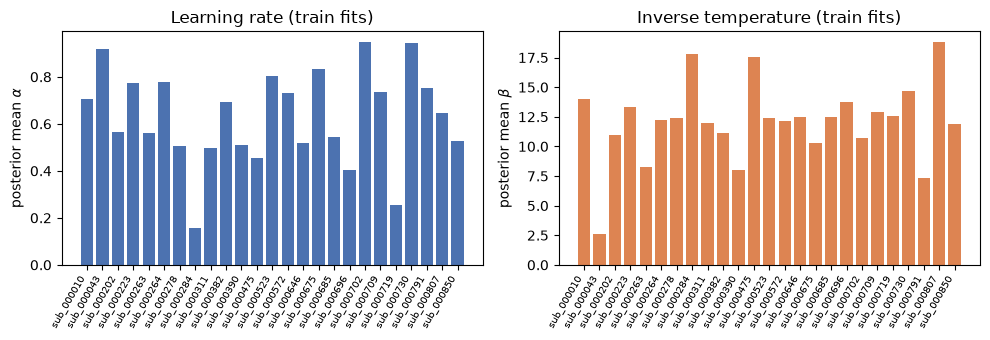

In [12]:
fig, axes = plot_parameter_summary(fit_summary)
plt.show()

## 6. Posterior predictive checks

The ssms simulator runs in `mode="ppc"`: it samples a choice from the
fitted softmax at each trial while advancing Q-values with the empirical
response/reward history. These are observed-history-conditioned,
one-step-ahead checks—not free counterfactual rollouts.

The held-out trajectory starts from `INITIAL_Q` and uses frozen fitted
parameters. Reward schedules are joined only after prediction to score
chosen latent reward; they never affect Q-values or probabilities.
The figure's y-axis is **Mean latent reward** on the normalized 0–1 scale.

In [13]:
latent_reward_summary, actual_k = run_latent_reward_ppc(
    fit_results,
    subjects,
    train,
    heldout,
    reward_schedules,
    n_simulations=N_PPC_SIMULATIONS,
    seed=SEED,
)
print("PPC participants:", len(subjects), "| simulations:", actual_k)

Simulating 5 train/held-out PPC datasets for 25 participants ...


PPC participants: 25 | simulations: 5


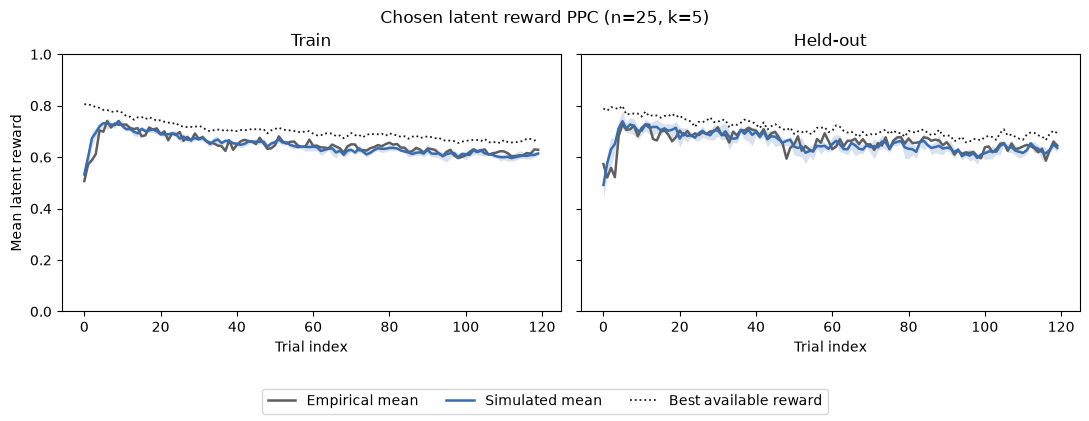

,split,trial_id,empirical_mean,simulated_mean,simulated_hdi_low,simulated_hdi_high,ceiling_mean,n_participants,n_simulations
0,heldout,0,0.5732,0.49208,0.4436,0.5412,0.7892,25,5
1,heldout,1,0.5208,0.57664,0.5248,0.6140,0.7808,25,5
2,heldout,2,0.5584,0.63072,0.5640,0.6792,0.7948,25,5
3,heldout,3,0.5220,0.65096,0.6200,0.6656,0.7912,25,5
4,heldout,4,0.6824,0.71336,0.6848,0.7428,0.7868,25,5


In [14]:
fig, axes = plot_latent_reward_ppc(
    latent_reward_summary,
    show_ceiling=SHOW_REWARD_CEILING,
)
fig.suptitle(
    f"Chosen latent reward PPC (n={len(subjects)}, k={actual_k})",
    y=1.02,
)
plt.show()
latent_reward_summary.head()

## 7. What to remember

1. **ssms defines the cognitive process:** task, learner, decision rule,
   sequential state, and simulator.
2. **HSSM defines the Bayesian model:** bridge, formulas, priors,
   `RLSSM`, sampling, and posterior representation.
3. `SimpleRescorlaWagnerSoftmax` predicts from pre-update Q-values and
   resets state explicitly at episode boundaries.
4. Parameters are frozen on held-out episodes; only Q-state updates
   online after observed choices and rewards.
5. The latent reward schedule is an analysis-only diagnostic and is
   never passed to fitting or prediction.